# One-session path traces and trajectory measurements

Run the notebook from top to bottom. The functions below keep **measurement**
separate from **plotting**, so display settings can change without reloading or
reprocessing the session.

The path grid follows `refactor_qc`: outbound/inbound columns, outcome or trial
rows, a shared first video frame, full-arena limits, and earlier-to-later trial
colours. Here the frame comes from **UndistortedVideoData**, matching DLC geometry.
Every path uses the configured **single keypoint**; a QC figure using a multi-point
centroid can therefore have a different trajectory even with matching layout.

`data-conduit` loads and aligns the session; `movement` processes the pose and
calculates path metrics. Matplotlib handles layouts and explanatory geometry.
Time remains recorded **session seconds** and space remains **pixels**. The
processing defaults are examples to review, not validated paper-analysis settings.

In [1]:
# ===============================================================================
# 1 | Locate This Checkout and Refresh Project Imports After Source Changes
# ===============================================================================

from pathlib import Path
from runpy import run_path

# --- 1.1 | Locate src/ from the checkout root or any notebook subdirectory -------
source_root = next((
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "src")
    if (candidate / "data_conduit").is_dir() and (candidate / "movement_figures").is_dir()
), None)
if source_root is None:
    raise FileNotFoundError("Open this notebook inside the data-conduit checkout.")

# --- 1.2 | Refresh cached project modules before importing the refactored API ----
# Load the bootstrap by file path: even a cached older package cannot shadow it.
# Rerun the following cells afterwards to rebuild data and figures consistently.
refresh_project_imports = run_path(
    str(source_root / "movement_figures" / "notebook_setup.py")
)["refresh_project_imports"]
source_root = refresh_project_imports(source_root)

# --- 1.3 | Import the analysis and plotting functions from this checkout ---------
from textwrap import fill
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import movement
import movement.kinematics as kin
from movement.plots import plot_centroid_trajectory
import numpy as np
import pandas as pd
from IPython.display import display

from data_conduit.datastructures import slice_stream
from data_conduit.integrations.DLC.pose import pose_to_movement
from movement_figures.data_template.loading import build_datastructure, prepare_pose
from movement_figures.video import read_session_video_frame
from movement_figures.timeseries_template.annotations import qc_annotations

print(f"movement {movement.__version__}: {movement.__file__}")


movement 0.17.0: /home/sepi/anaconda3/envs/data-conduit-refactor/lib/python3.12/site-packages/movement/__init__.py


## Choose the session and display settings

In [2]:
#=== 2| Session selection and display controls =================================
"""Choose one session; preserve pixel coordinates and the recorded clock in seconds."""

ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")
SESSION = "2026-06-21T093349Z"
LEVEL_NAMES = ("mouseID", "day")  # ROOT / mouseID / day / SESSION.
LEVEL_SELECTORS = {"l0_selector": "MR_M01569515", "l1_selector": "Day21"}
SOURCES = ("trials", "events", "dlc")

# Use one fixed point in every panel, instead of a centroid that changes when
# different keypoints disappear. The QC plotter can use a different centroid.
INDIVIDUAL = "individual_0"
TRACKING_KEYPOINT = "body"
CONFIDENCE_THRESHOLD = 0.9
MAX_GAP_FRAMES = None  # Preserve missing positions; no interpolation by default.
SMOOTHING_WINDOW = None  # Optional rolling median window, in recorded samples.

# Row numbers refer to the displayed, time-sorted trial table; they start at zero.
TRIAL_ROWS = (0, 1, 2)
PATH_GROUP_BY = "outcome"  # "outcome", "session", or "trial".
PATH_CMAP = "Blues"  # Earlier session trials are lighter, later trials darker.
PATH_POINT_SIZE = 4
PATH_ALPHA = 0.70
BACKGROUND_ALPHA = 0.55
ARENA_RANGE = None  # Optional ((xmin, xmax), (ymin, ymax)), in original pixels.

# None shows the first VALID trial for each metric and names the chosen row.
# To inspect particular rows instead: {"outbound": 0, "inbound": 0}.
EXAMPLE_TRIAL_ROWS = None


## Load once and inspect the selected session

In [3]:
# Load one recording through the current native DataStructure interface.
session_data = build_datastructure(
    ROOT, level_names=LEVEL_NAMES, include=(SESSION,), streams=SOURCES,
    **(LEVEL_SELECTORS or {}),
)
recording_refs = session_data.select()
if len(recording_refs) != 1:
    raise ValueError("Select exactly one recording using SESSION and LEVEL_SELECTORS.")
session_id, session_ref = next(iter(recording_refs.items()))
session_path = session_ref.path
display(pd.DataFrame([
    {"session": session_id, "path": str(session_path), **session_ref.levels}
]))
streams = session_data.load()
raw_pose = pose_to_movement(
    slice_stream(streams["dlc:position"], selectors={"session": session_id}),
    slice_stream(streams["dlc:confidence"], selectors={"session": session_id}),
)
pose = prepare_pose(
    raw_pose,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    max_gap_frames=MAX_GAP_FRAMES,
    smoothing_window=SMOOTHING_WINDOW,
)
position = pose.position.sel(individual=INDIVIDUAL, drop=True)
point = position.sel(keypoint=TRACKING_KEYPOINT, drop=True)
trials = slice_stream(streams["trials"], selectors={"session": session_id})
trials = trials.sort_values("start_time", kind="stable").reset_index(drop=True)
events = slice_stream(streams["events"], selectors={"session": session_id})
display(trials)
for note in qc_annotations(trials, events).notes:
    print(note)
print("Keypoints:", position.keypoint.values.tolist())
print("Valid tracked-point frames:", int(point.notnull().all("space").sum()), "/", point.sizes["time"])

# Use this recording's camera frame in the same coordinates as its DLC tracking.
background_frame, background_video_path = read_session_video_frame(session_path)
session_label = " / ".join(session_path.parts[-(len(LEVEL_NAMES) + 1):])
print(f"Background: first frame of {background_video_path}")


,session,path,mouseID,day
0,2026-06-21T093349Z,/media/sepi/Elements/PathIntegrationProtocol/B...,MR_M01569515,Day21



                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  


,trial_index,start_time,end_time,start_inclusive,end_inclusive,first_event_index,last_event_index,tz_triggered_time,tz_available_time,ChosenPort,...,outbound_end_time,outbound_start_inclusive,outbound_end_inclusive,inbound_start_time,inbound_end_time,inbound_start_inclusive,inbound_end_inclusive,session,mouseID,day
0,1,5633.836992,5667.029120,True,True,1,12,5663.198976,5640.910976,0,...,5663.198976,True,True,5663.198976,5667.029120,True,True,2026-06-21T093349Z,MR_M01569515,Day21
1,2,5667.029120,5681.075968,False,True,13,27,5678.849984,5675.540992,0,...,5678.849984,False,True,5678.849984,5681.075968,True,True,2026-06-21T093349Z,MR_M01569515,Day21
2,3,5681.075968,5695.245088,False,True,28,42,5693.349984,5690.241984,0,...,5693.349984,False,True,5693.349984,5695.245088,True,True,2026-06-21T093349Z,MR_M01569515,Day21
3,4,5695.245088,5709.933824,False,True,43,56,5707.698976,5697.756000,0,...,5707.698976,False,True,5707.698976,5709.933824,True,True,2026-06-21T093349Z,MR_M01569515,Day21
4,5,5709.933824,5721.442080,False,True,57,71,5719.708992,5719.392000,0,...,5719.708992,False,True,5719.708992,5721.442080,True,True,2026-06-21T093349Z,MR_M01569515,Day21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,102,7311.543744,7328.291776,False,True,1409,1422,7325.601984,7319.292384,0,...,7325.601984,False,True,7325.601984,7328.291776,True,True,2026-06-21T093349Z,MR_M01569515,Day21
102,103,7328.291776,7349.316480,False,True,1423,1436,7344.304000,7335.678976,-1,...,7344.304000,False,True,7344.304000,7349.316480,True,True,2026-06-21T093349Z,MR_M01569515,Day21
103,104,7349.316480,7370.981504,False,True,1437,1449,7365.952992,7356.648000,-1,...,7365.952992,False,True,7365.952992,7370.981504,True,True,2026-06-21T093349Z,MR_M01569515,Day21
104,105,7370.981504,7417.264352,False,True,1450,1462,7414.952992,7379.677984,0,...,7414.952992,False,True,7414.952992,7417.264352,True,True,2026-06-21T093349Z,MR_M01569515,Day21


Keypoints: ['nose', 'lear', 'rear', 'body', 'tailbase']
Valid tracked-point frames: 35654 / 36354
Background: first frame of /media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training/MR_M01569515/Day21/2026-06-21T093349Z/UndistortedVideoData/Training_MR_M01569515_Day21_093349Z.avi


## Measure phases before plotting

**Outbound straightness = D/L**: distance between the observed start and end
positions divided by travelled distance. A straight path gives 1; a less direct
path gives a lower value. This measures directness, not a general search strategy.

**Inbound deviation**: unsigned perpendicular distance to the **infinite line
through the observed inbound endpoints**, averaged equally over recorded samples.
It is not error relative to the home port or intended return direction.

Both metrics keep the original strict exclusions. A phase needs valid start,
target-trigger and end times, complete pose-clock coverage, at least two samples,
and finite tracked coordinates throughout. Missing timestamps require separate
acquisition-clock inspection. No missing coordinates are filled during measurement.

The old selected-trial panels could be empty because the first chosen rows had
tracking gaps and were excluded. The geometry figure now explicitly names the
first valid example for each phase; the summary shows all exclusions beside the
session measurements. Set `EXAMPLE_TRIAL_ROWS` to inspect a particular row instead.

In [4]:
#=== 4| Measure phases and retain an explicit eligibility report ================
def measure_trial_paths(point, trials):
    """Return strict phase metrics, observed phase paths, and inbound deviations.

    Parameters
    ----------
    point : xarray.DataArray
        One processed keypoint with dimensions (time, space), x/y in pixels and
        time on the recorded session clock in seconds. No filtering occurs here.
    trials : pandas.DataFrame
        One session's table, sorted by start_time, with a unique zero-based row
        index and start_time, tz_triggered_time, end_time, and outcome columns.

    Returns
    -------
    metrics : pandas.DataFrame
        One row per trial/phase. Includes duration_s, n_samples, n_valid_samples,
        path_straightness, path_length_px, endpoint_distance_px,
        mean_deviation_px, and status. Unavailable metrics are NaN.
    phase_paths : dict[(int, str), xarray.DataArray]
        Observed samples keyed by (trial_row, phase). Missing positions stay
        missing; invalid phase boundaries produce an empty array.
    inbound_deviations : dict[int, xarray.DataArray]
        movement's per-sample perpendicular distances (px), for valid inbound
        phases only. Their arithmetic sample mean is the reported deviation.

    Notes
    -----
    Outbound runs from trial start to target trigger; inbound from trigger to
    trial end, matching refactor_qc. Label slices include both bounds, so a sample
    exactly at the trigger is a shared endpoint. A metric requires ordered finite
    event times, full pose-clock coverage, at least two samples and NO nonfinite
    coordinates. This prevents movement's path-length default from filling gaps.
    Timestamp gaps are not detected by this coordinate-validity check.
    """
    #=== 1| Validate one session and a strictly increasing seconds clock =========
    required_columns = {"start_time", "tz_triggered_time", "end_time", "outcome"}
    missing_columns = sorted(required_columns - set(trials.columns))
    if missing_columns:
        raise ValueError(f"trials is missing required columns: {missing_columns}")
    if set(point.dims) != {"time", "space"} or set(point.space.values) != {"x", "y"}:
        raise ValueError("point must be one x/y keypoint with dimensions time and space.")
    if point.sizes["time"] == 0 or trials.empty:
        raise ValueError("A nonempty point array and trial table are required.")
    if list(trials.index) != list(range(len(trials))):
        raise ValueError("Sort trials by start_time and reset their index before measuring.")
    times = np.asarray(point.time, dtype=float)
    if not np.isfinite(times).all() or not bool((np.diff(times) > 0).all()):
        raise ValueError("point.time must contain finite, strictly increasing session seconds.")
    if "session" in trials and (trials.session.isna().any() or trials.session.nunique() != 1):
        raise ValueError("trials must identify exactly one session.")

    #=== 2| Slice each outbound/inbound phase without filling coordinates ========
    records, phase_paths, inbound_deviations = [], {}, {}
    pose_start, pose_end = float(point.time.min()), float(point.time.max())
    for trial_row, trial in trials.iterrows():
        # Treat every pandas missing-value representation as an absent event.
        start, split, end = (
            np.nan if pd.isna(value) else float(value)
            for value in (trial.start_time, trial.tz_triggered_time, trial.end_time)
        )
        boundary_valid = np.isfinite([start, split, end]).all() and start < split < end
        for phase, bounds in [("outbound", (start, split)), ("inbound", (split, end))]:
            # Retain observed positions even for an excluded metric so the grid
            # can show where the animal was tracked without filling missing data.
            segment = (
                point.sel(time=slice(*bounds))
                if boundary_valid
                else point.isel(time=slice(0, 0))
            )
            phase_paths[(trial_row, phase)] = segment
            record = {
                "trial_row": trial_row,
                "phase": phase,
                "outcome": trial.outcome if pd.notna(trial.outcome) else "Unknown",
                "duration_s": np.nan,
                "n_samples": segment.sizes["time"],
                "n_valid_samples": int(np.isfinite(segment).all("space").sum()),
                "path_straightness": np.nan,
                "path_length_px": np.nan,
                "endpoint_distance_px": np.nan,
                "mean_deviation_px": np.nan,
                "status": "",
            }
            #=== 3| Record an exclusion or calculate the phase's metric =========
            if not boundary_valid:
                record["status"] = "no valid target-trigger phase boundary"
            elif bounds[0] < pose_start or bounds[1] > pose_end:
                record["status"] = "incomplete pose time coverage"
            else:
                record["duration_s"] = bounds[1] - bounds[0]
                if segment.sizes["time"] < 2:
                    record["status"] = "fewer than two pose samples"
                elif not bool(np.isfinite(segment).all()):
                    record["status"] = "unfilled tracking gaps"
                elif phase == "outbound":
                    # movement supplies D/L and L. The endpoint distance D below
                    # is ordinary Euclidean geometry, retained to explain D/L.
                    value = float(kin.compute_path_straightness(segment))
                    record["path_straightness"] = value
                    record["path_length_px"] = float(kin.compute_path_length(segment))
                    record["endpoint_distance_px"] = float(np.linalg.norm(
                        segment.isel(time=-1).values - segment.isel(time=0).values
                    ))
                    record["status"] = "ok" if np.isfinite(value) else "undefined: zero path length"
                elif bool((segment.isel(time=0) == segment.isel(time=-1)).all()):
                    record["status"] = "undefined: coincident endpoints"
                else:
                    deviation = kin.compute_path_deviation(segment)
                    inbound_deviations[trial_row] = deviation
                    record["mean_deviation_px"] = float(deviation.mean("time"))
                    record["status"] = "ok"
            records.append(record)

    #=== 4| Return reusable measurements and the observations behind them ========
    return pd.DataFrame(records), phase_paths, inbound_deviations

In [5]:
#=== 5| Example call: measure all trials without changing processing =============
metrics, phase_paths, inbound_deviations = measure_trial_paths(point, trials)
display(metrics)

# Counts are per phase: one trial contributes one outbound and one inbound row.
exclusion_counts = (
    metrics.groupby(["phase", "status"], sort=False)
    .size()
    .rename("n_trial_phases")
    .reset_index()
)
display(exclusion_counts)

,trial_row,phase,outcome,duration_s,n_samples,n_valid_samples,path_straightness,path_length_px,endpoint_distance_px,mean_deviation_px,status
0,0,outbound,Success,29.361984,587,584,NaN,NaN,NaN,NaN,unfilled tracking gaps
1,0,inbound,Success,3.830144,76,75,NaN,NaN,NaN,NaN,unfilled tracking gaps
2,1,outbound,Success,11.820864,237,232,NaN,NaN,NaN,NaN,unfilled tracking gaps
3,1,inbound,Success,2.225984,44,44,NaN,NaN,NaN,160.429861,ok
4,2,outbound,Success,12.274016,246,241,NaN,NaN,NaN,NaN,unfilled tracking gaps
...,...,...,...,...,...,...,...,...,...,...,...
207,103,inbound,Miss,5.028512,100,100,NaN,NaN,NaN,87.797544,ok
208,104,outbound,Success,43.971488,880,855,NaN,NaN,NaN,NaN,unfilled tracking gaps
209,104,inbound,Success,2.311360,46,46,NaN,NaN,NaN,143.893528,ok
210,105,outbound,Success,24.537632,491,413,NaN,NaN,NaN,NaN,unfilled tracking gaps


,phase,status,n_trial_phases
0,outbound,unfilled tracking gaps,77
1,inbound,unfilled tracking gaps,46
2,inbound,ok,60
3,outbound,ok,29


## Paths over the arena: outcome rows × phase columns

The same trial has the same colour in both columns. Counts distinguish paths
that can be shown from phases with valid metrics: a few missing samples still
allow an observed path to be displayed, while the strict metric remains excluded.
Empty phase panels retain the frame and report the absence of paths.

Change `PATH_GROUP_BY` to `"trial"` for individual rows listed in `TRIAL_ROWS`, or
to `"session"` for one pooled row. Marker size, opacity and arena crop are display
controls; they do not change the measurements.

In [6]:
# ===============================================================================
#=== 6| Common arena background and pixel limits ================================
# ===============================================================================

def draw_arena(ax, frame, *, arena_range=None, background_alpha=0.55, show_ticks=False):
    """Draw the recording's first video frame in its original pixel coordinates.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Existing spatial axes to receive the frame and coordinate limits.
    frame : numpy.ndarray
        Nonempty first RGB/RGBA video frame with shape (height, width, 3 or 4),
        from the same recording and camera geometry as the tracked positions.
        Integer x/y coordinates refer to pixel centres, including (0, 0).
    arena_range : tuple[tuple[float, float], tuple[float, float]] | None
        Optional ((xmin, xmax), (ymin, ymax)) crop in pixels. None uses the full
        image edges, from -0.5 to width/height minus 0.5.
    background_alpha : float
        Image opacity in [0, 1]; the default keeps paths visible over the frame.
    show_ticks : bool
        True labels x/y in pixels; False hides ticks for compact path grids.

    Returns
    -------
    matplotlib.axes.Axes
        The supplied axes, with equal spatial scaling and y increasing downward.
        Drawing never resizes, flips or otherwise transforms the tracked points.
    """
    #=== 1| Validate the frame, opacity and optional pixel crop ==================
    frame = np.asarray(frame)
    if frame.ndim != 3 or frame.shape[2] not in (3, 4) or min(frame.shape[:2]) == 0:
        raise ValueError("frame must be a nonempty RGB or RGBA image.")
    height, width = frame.shape[:2]
    if not 0 <= background_alpha <= 1:
        raise ValueError("background_alpha must lie between 0 and 1.")
    frame_extent = (-0.5, width - 0.5, height - 0.5, -0.5)  # Align integer DLC coordinates with image pixel centres.
    limits = ((frame_extent[0], frame_extent[1]), (frame_extent[3], frame_extent[2])) if arena_range is None else arena_range
    if np.shape(limits) != (2, 2) or not np.isfinite(limits).all():
        raise ValueError("arena_range must be two finite (minimum, maximum) pairs.")
    if any(lower >= upper for lower, upper in limits):
        raise ValueError("Each arena_range minimum must be smaller than its maximum.")

    #=== 2| Draw in image coordinates and keep equal spatial scaling =============
    ax.imshow(frame, origin="upper", extent=frame_extent, alpha=background_alpha)
    ax.set(xlim=limits[0], ylim=limits[1][::-1], aspect="equal")
    if show_ticks:
        ax.set(xlabel="x (px)", ylabel="y (px)")
        ax.tick_params(labelsize=9)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
    return ax

In [7]:
# ===============================================================================
#=== 7| QC-style phase grid for one session ======================================
# ===============================================================================

def plot_session_path_grid(
    phase_paths,
    metrics,
    frame,
    *,
    group_by="outcome",
    trial_rows=None,
    session_label="Selected session",
    tracking_keypoint="body",
    arena_range=None,
    cmap="Blues",
    marker_size=4,
    path_alpha=0.70,
    background_alpha=0.55,
):
    """Draw outbound/inbound samples over the recording's first video frame.

    Parameters
    ----------
    phase_paths : dict[tuple[int, str], xarray.DataArray]
        Observed x/y paths in pixels keyed by (trial_row, phase), returned by
        measure_trial_paths. Missing samples remain missing during drawing.
    metrics : pandas.DataFrame
        The complete session measurement table from measure_trial_paths, with
        trial_row, phase, outcome, n_valid_samples and status columns. Full
        session trial rows determine the colour scale even when showing a subset.
    frame : numpy.ndarray
        First RGB/RGBA frame from this session's video, in the same original
        pixel geometry as phase_paths. The frame is required for every panel.
    group_by : str
        'outcome' creates outcome rows, 'session' creates one overlaid row, and
        'trial' creates one row per selected zero-based trial row.
    trial_rows : iterable[int] | None
        Optional zero-based trial-table rows to display, for any group_by value.
        None includes all supplied trials. Unknown or empty selections raise.
    session_label : str
        Recording identity printed in the figure title.
    tracking_keypoint : str
        Name of the fixed tracked point, used in the title only.
    arena_range : tuple[tuple[float, float], tuple[float, float]] | None
        Optional ((xmin, xmax), (ymin, ymax)) crop in original pixels.
        None uses the complete video frame; y increases downward.
    cmap : str
        Matplotlib colour map for chronological trial order. Its palest quarter
        is omitted so earlier paths remain visible over the frame.
    marker_size : float
        Positive scatter-marker area in points squared.
    path_alpha : float
        Sample opacity in (0, 1].
    background_alpha : float
        Video-frame opacity in [0, 1].

    Returns
    -------
    figure : matplotlib.figure.Figure
        Spatial grid with a shared chronological trial colourbar.
    axes : numpy.ndarray
        Two-dimensional axes array, with one row per group and two phase columns.
    plot_report : pandas.DataFrame
        Copy of selected trial/phase rows with path_shown added. A path with at
        least two finite observations is drawable even if gaps exclude its metric.
        No measurements are changed, filled, fitted or recomputed.
    """
    #=== 1| Select trials and distinguish drawable paths from valid metrics ======
    if group_by not in {"outcome", "session", "trial"}:
        raise ValueError("group_by must be 'outcome', 'session', or 'trial'.")
    if not 0 < path_alpha <= 1 or marker_size <= 0:
        raise ValueError("path_alpha must be in (0, 1] and marker_size must be positive.")
    selected = metrics.copy()
    if trial_rows is not None:
        missing = sorted(set(trial_rows) - set(metrics.trial_row))
        if missing:
            raise ValueError(f"Unknown trial rows: {missing}")
        selected = selected[selected.trial_row.isin(trial_rows)].copy()
    if selected.empty:
        raise ValueError("Select at least one trial to plot.")
    selected["path_shown"] = selected.n_valid_samples >= 2

    #=== 2| Choose row groups and one consistent chronological colour scale ======
    if group_by == "outcome":
        present = selected.outcome.unique().tolist()
        groups = [name for name in ("Success", "Miss", "Failure") if name in present]
        groups += [name for name in present if name not in groups]
        selected["plot_group"] = selected.outcome
    elif group_by == "trial":
        groups = sorted(selected.trial_row.unique())
        selected["plot_group"] = selected.trial_row
    else:
        groups = ["All trials"]
        selected["plot_group"] = "All trials"

    # Truncate the pale end for contrast against the camera frame, as in QC.
    trial_cmap = LinearSegmentedColormap.from_list(
        "session_trials", mpl.colormaps[cmap](np.linspace(0.25, 1, 256))
    )
    first_row, last_row = int(metrics.trial_row.min()), int(metrics.trial_row.max())
    trial_norm = Normalize(first_row, max(first_row + 1, last_row))
    fig, axes = plt.subplots(
        len(groups), 2, figsize=(12, 4.6 * len(groups)),
        squeeze=False, layout="constrained",
    )

    #=== 3| Render observed samples over the same arena in every panel ===========
    for group_index, group in enumerate(groups):
        for phase_index, phase in enumerate(("outbound", "inbound")):
            ax = axes[group_index, phase_index]
            draw_arena(ax, frame, arena_range=arena_range, background_alpha=background_alpha)
            panel = selected[(selected.plot_group == group) & (selected.phase == phase)]
            for record in panel.itertuples():
                if not record.path_shown:
                    continue
                segment = phase_paths[(record.trial_row, phase)]
                # Mask whole x/y pairs. Missing samples stay missing and are never
                # connected by a line or replaced by interpolated coordinates.
                observed = segment.where(np.isfinite(segment).all("space"))
                plot_centroid_trajectory(
                    observed, ax=ax,
                    c=mpl.colors.to_hex(trial_cmap(trial_norm(record.trial_row))),
                    s=marker_size, alpha=path_alpha, linewidths=0,
                )

            shown, valid = int(panel.path_shown.sum()), int((panel.status == "ok").sum())
            ax.text(
                0.025, 0.975, f"Paths shown: {shown}/{len(panel)}\nValid metrics: {valid}/{len(panel)}",
                transform=ax.transAxes, va="top", fontsize=10,
                bbox=dict(facecolor="white", alpha=0.90, edgecolor="none", pad=5),
            )
            if shown == 0:
                ax.text(
                    0.5, 0.5, "No drawable phase paths\nSee the report below",
                    transform=ax.transAxes, ha="center", va="center", fontsize=11,
                    bbox=dict(facecolor="white", alpha=0.90, edgecolor="none", pad=6),
                )
            # Restore image limits after movement draws samples: points outside
            # the selected crop must not stretch or reverse the camera geometry.
            height, width = frame.shape[:2]
            limits = ((-0.5, width - 0.5), (-0.5, height - 0.5)) if arena_range is None else arena_range
            ax.set(xlim=limits[0], ylim=limits[1][::-1], aspect="equal")
            # Reset movement's own labels/titles after every panel is complete.
            ax.set_title(phase.capitalize() if group_index == 0 else "", fontsize=14)
            ax.set_xlabel("")
            row_label = f"Trial row {group}" if group_by == "trial" else str(group)
            if group_by == "trial":
                row_label += f"\n{panel.outcome.iloc[0]}"
            ax.set_ylabel(row_label if phase_index == 0 else "", fontsize=12)

    #=== 4| Add a shared legend and return a per-phase plotting report ============
    colourbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=trial_norm, cmap=trial_cmap),
        ax=axes.ravel().tolist(), fraction=0.025, pad=0.025,
    )
    colourbar.set_ticks([first_row, last_row] if last_row > first_row else [first_row])
    colourbar.set_label("Trial row: earlier → later", fontsize=11)
    fig.suptitle(
        f"{session_label}\n{tracking_keypoint} paths · first undistorted video frame",
        fontsize=15,
    )
    return fig, axes, selected.drop(columns="plot_group")

## Read the geometry on a named trial

The left example separates travelled distance **L** from endpoint distance **D**.
The right example draws a few perpendicular distances to the infinite endpoint
line; the displayed mean uses **every recorded sample** in that valid inbound phase.
The two examples may come from different trials, identified in their panel titles.
These are explanatory examples, not selected evidence of a session-wide effect.
Both geometric panels use this recording’s **first video frame**, with pixel-centre alignment and the same optional arena crop as the path grid.


In [8]:
# ===============================================================================
#=== 8| Explain each metric on an explicitly identified real trial ===============
# ===============================================================================

def plot_metric_geometry(
    phase_paths,
    metrics,
    inbound_deviations,
    frame,
    *,
    trial_rows=None,
    session_label="Selected session",
    arena_range=None,
    background_alpha=0.55,
):
    """Explain measured path geometry on named trials over the first video frame.

    Parameters
    ----------
    phase_paths : dict[tuple[int, str], xarray.DataArray]
        Observed x/y paths in pixels keyed by (trial_row, phase), as returned by
        measure_trial_paths. Missing observations produce line breaks.
    metrics : pandas.DataFrame
        Session measurement rows from measure_trial_paths, containing both phases,
        eligibility status, counts and their measured distances/straightness.
    inbound_deviations : dict[int, xarray.DataArray]
        Eligible inbound per-sample distances to the infinite endpoint line, in
        pixels, returned by measure_trial_paths and keyed by trial_row.
    frame : numpy.ndarray
        This recording's first RGB/RGBA video frame. Both panels use the same
        original pixel coordinates as their observed paths; no fallback is made.
    trial_rows : dict[str, int] | None
        Optional explicit zero-based trial row per 'outbound'/'inbound' phase.
        An unspecified phase uses its first eligible trial, or its first excluded
        row if none is eligible. The choice appears in the title and report.
    session_label : str
        Recording identity printed in the figure title.
    arena_range : tuple[tuple[float, float], tuple[float, float]] | None
        Optional ((xmin, xmax), (ymin, ymax)) crop in pixels. None uses the full
        first frame; equal x/y scaling and downward y preserve camera geometry.
    background_alpha : float
        Video-frame opacity in [0, 1].

    Returns
    -------
    figure : matplotlib.figure.Figure
        Two spatial panels illustrating outbound straightness and inbound
        deviation. Their video backgrounds anchor geometry in the actual arena.
    axes : numpy.ndarray
        One-dimensional array of outbound and inbound Matplotlib axes.
    example_report : pandas.DataFrame
        Selected phase/trial rows, selection reasons, eligibility status and
        session-wide valid/excluded counts for each phase.

    Notes
    -----
    Outbound draws travelled length L and endpoint distance D; its D/L value is
    the existing movement straightness result. Inbound draws the infinite
    endpoint line and a few illustrative perpendicular projections. Reported
    deviation still uses every recorded sample, equally, from movement's result.
    The function never recomputes, interpolates or fits measurement values.
    """
    #=== 1| Validate example selection and identify each example transparently ===
    if metrics.empty or not {"outbound", "inbound"}.issubset(set(metrics.phase)):
        raise ValueError("metrics must contain both outbound and inbound phase rows.")
    if trial_rows is not None and set(trial_rows) - {"outbound", "inbound"}:
        raise ValueError("trial_rows keys must be 'outbound' and/or 'inbound'.")
    fig, axes = plt.subplots(1, 2, figsize=(14, 7.2), layout="constrained")
    example_records = []
    for ax, phase in zip(axes, ("outbound", "inbound")):
        phase_metrics = metrics[metrics.phase == phase].sort_values("trial_row")
        valid = phase_metrics[phase_metrics.status == "ok"]
        if trial_rows is not None and phase in trial_rows:
            candidates = phase_metrics[phase_metrics.trial_row == trial_rows[phase]]
            if candidates.empty:
                raise ValueError(f"No {phase} metric row for trial {trial_rows[phase]}.")
            record, selection = candidates.iloc[0], "requested example"
        elif not valid.empty:
            record, selection = valid.iloc[0], f"first valid {phase}"
        else:
            record, selection = phase_metrics.iloc[0], "first row; no valid example"

        trial_row = int(record.trial_row)
        example_records.append({
            "phase": phase, "trial_row": trial_row, "selection": selection,
            "status": record.status, "valid_phases": len(valid),
            "excluded_phases": len(phase_metrics) - len(valid),
        })
        #=== 2| Display only the observed path, with breaks at missing samples ===
        segment = phase_paths[(trial_row, phase)]
        draw_arena(
            ax, frame, arena_range=arena_range,
            background_alpha=background_alpha, show_ticks=True,
        )
        coordinates = segment.sel(space=["x", "y"]).transpose("time", "space").values
        # NaN rows break the line at missing observations, including half-valid x/y.
        coordinates = np.where(np.isfinite(coordinates).all(axis=1)[:, None], coordinates, np.nan)
        if int(record.n_valid_samples) >= 2:
            # Mark individual samples too: an isolated valid observation next
            # to a gap has no line segment, but should still remain visible.
            ax.plot(
                *coordinates.T, color="#176a9b", linewidth=1.7,
                marker=".", markersize=3, label="Observed path", zorder=3,
            )

        #=== 3| Draw metric geometry only for an eligible phase ==================
        if record.status == "ok":
            start, end = coordinates[0], coordinates[-1]
            ax.scatter(*start, c="white", edgecolors="black", s=55, marker="o", zorder=6, label="Start")
            ax.scatter(*end, c="black", edgecolors="white", s=55, marker="s", zorder=6, label="End")
            if phase == "outbound":
                ax.plot(
                    *np.vstack([start, end]).T, color="#b96500", linestyle="--",
                    linewidth=2.2, label="Endpoint distance D", zorder=4,
                )
                explanation = (
                    f"Endpoint distance D = {record.endpoint_distance_px:.1f} px\n"
                    f"Travelled distance L = {record.path_length_px:.1f} px\n"
                    f"Straightness D/L = {record.path_straightness:.3f}"
                )
            else:
                ax.axline(
                    start, end, color="#b96500", linestyle="--", linewidth=2,
                    label="Infinite endpoint line", zorder=2,
                )
                deviation = inbound_deviations[trial_row]
                # Sparse projections explain the perpendicular-distance geometry;
                # the reported mean still uses every recorded sample, equally.
                indices = np.unique(np.r_[
                    np.linspace(0, len(coordinates) - 1, min(9, len(coordinates)), dtype=int),
                    int(deviation.argmax("time")),
                ])
                samples = coordinates[indices]
                unit_direction = (end - start) / np.linalg.norm(end - start)
                feet = start + np.outer((samples - start) @ unit_direction, unit_direction)
                for index, (sample, foot) in enumerate(zip(samples, feet)):
                    ax.plot(
                        *np.vstack([sample, foot]).T, color="#9e3f91", linewidth=1.6,
                        label="Perpendicular distances" if index == 0 else None, zorder=4,
                    )
                explanation = (
                    f"Mean perpendicular distance = {record.mean_deviation_px:.1f} px\n"
                    f"Mean of {int(record.n_samples)} recorded samples"
                )
        else:
            explanation = (
                "Metric excluded\n" + fill(record.status, 38) +
                f"\nFinite samples: {int(record.n_valid_samples)}/{int(record.n_samples)}"
            )

        #=== 4| Label the measurement, source trial and session exclusions ========
        ax.text(
            0.025, 0.025, explanation, transform=ax.transAxes, va="bottom", fontsize=10,
            bbox=dict(facecolor="white", alpha=0.94, edgecolor="none", pad=6),
        )
        metric_label = "Straightness: D ÷ L" if phase == "outbound" else "Deviation: distance to endpoint line"
        ax.set_title(
            f"{phase.capitalize()} · {metric_label}\n"
            f"Trial row {trial_row} · {record.outcome} · {selection}\n"
            f"Session: {len(valid)} valid / {len(phase_metrics) - len(valid)} excluded",
            fontsize=11, pad=12,
        )
        if ax.get_legend_handles_labels()[0]:
            ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)

    #=== 5| Return the figure and the exact example-selection report =============
    fig.suptitle(f"{session_label}\nWhat each path measurement means", fontsize=15)
    return fig, axes, pd.DataFrame(example_records)

## Session summary and eligibility

Each top-row dot is one eligible phase at its chronological trial row, coloured
by outcome. Missing dots correspond to the explicit phase-status counts below.
The two measurements have different units and meanings; they are shown separately
without a fitted relationship. Review exclusions before comparing outcomes.
These trial-order and count axes are measurement summaries, not camera x/y coordinates; their video context is shown in the spatial path panels above.


In [9]:
# ===============================================================================
#=== 9| Session measurements and their exclusion counts ==========================
# ===============================================================================

def plot_trajectory_summary(metrics, *, session_label="Selected session", outcome_colors=None):
    """Plot trial-order measurements and phase exclusion counts for one recording.

    Parameters
    ----------
    metrics : pandas.DataFrame
        Session table returned by measure_trial_paths, with trial_row, phase,
        outcome, status, path_straightness and mean_deviation_px columns. Both
        phases must be present; excluded rows remain available for status counts.
    session_label : str
        Recording identity printed in the figure title.
    outcome_colors : dict[str, str] | None
        Optional outcome-to-Matplotlib-colour overrides. Unknown outcomes are grey.

    Returns
    -------
    figure : matplotlib.figure.Figure
        Figure showing individual eligible measurements and exclusion counts.
    axes : numpy.ndarray
        A (2, 2) array: columns are outbound/inbound, top row shows measured values
        by zero-based trial row, and bottom row counts every eligibility status.

    Notes
    -----
    D/L is unitless and inbound deviation is in pixels. These axes compare
    measurements with trial order or counts; they are not camera x/y coordinates,
    so a video background would imply a false spatial correspondence. Camera
    frames appear in the path grid and geometric examples instead. No values
    are pooled between phases, imputed, fitted or smoothed.
    """
    #=== 1| Prepare two phase panels and a stable outcome colour key ==============
    if metrics.empty or not {"outbound", "inbound"}.issubset(set(metrics.phase)):
        raise ValueError("metrics must contain both outbound and inbound phase rows.")
    colors = {"Success": "#23775a", "Miss": "#c27b12", "Failure": "#b94148", "Unknown": "#657183"}
    colors.update(outcome_colors or {})
    fig, axes = plt.subplots(2, 2, figsize=(14, 8.5), layout="constrained")
    definitions = (
        ("outbound", "path_straightness", "Outbound straightness", "Endpoint distance / travelled distance (D/L)"),
        ("inbound", "mean_deviation_px", "Mean inbound deviation", "Mean distance to endpoint line (px)"),
    )
    #=== 2| Plot eligible measurements in recorded trial order ===================
    for column, (phase, value_column, title, ylabel) in enumerate(definitions):
        phase_metrics = metrics[metrics.phase == phase]
        valid = phase_metrics[phase_metrics.status == "ok"]
        ax = axes[0, column]
        for outcome, rows in valid.groupby("outcome", sort=False):
            ax.scatter(
                rows.trial_row, rows[value_column], s=28, alpha=0.85,
                color=colors.get(outcome, "#657183"), label=outcome,
            )
        ax.set(
            xlabel="Trial row (zero-based, chronological)", ylabel=ylabel,
            title=f"{title}\n{len(valid)}/{len(phase_metrics)} valid; {len(phase_metrics) - len(valid)} excluded",
            xlim=(float(phase_metrics.trial_row.min()) - 1, float(phase_metrics.trial_row.max()) + 1),
        )
        if phase == "outbound":
            ax.set_ylim(-0.03, 1.03)
        else:
            ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)
        if valid.empty:
            ax.text(
                0.5, 0.5, "No eligible measurements\nSee the exclusion counts below",
                transform=ax.transAxes, ha="center", va="center", fontsize=12,
            )
        else:
            ax.legend(title="Trial outcome", fontsize=9, title_fontsize=9)

        #=== 3| Count valid and excluded phases beside the measurement panels ====
        # Counts explicitly explain holes in the trial-order scatter above.
        ax = axes[1, column]
        counts = phase_metrics.status.value_counts()
        reasons = (["ok"] if "ok" in counts else []) + [r for r in counts.index if r != "ok"]
        values = [int(counts[reason]) for reason in reasons]
        labels = ["Valid metric" if reason == "ok" else fill(reason, 25) for reason in reasons]
        bars = ax.barh(
            labels, values,
            color=["#23775a" if reason == "ok" else "#87919b" for reason in reasons],
            height=0.65,
        )
        ax.bar_label(
            bars, labels=[f"{count} ({count / len(phase_metrics):.0%})" for count in values],
            padding=5, fontsize=10,
        )
        ax.set(
            xlabel="Number of trial phases", title=f"{phase.capitalize()} eligibility · {len(phase_metrics)} trials",
            xlim=(0, max(values, default=1) * 1.35),
        )
        ax.invert_yaxis()
        ax.grid(axis="x", alpha=0.15)
        ax.set_axisbelow(True)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    #=== 4| Return the assembled figure without changing any measurements =========
    fig.suptitle(f"{session_label}\nPath metrics across the session", fontsize=15)
    return fig, axes

In [10]:
#=== 10| Compact secondary table for the trials displayed in the path grid ======
def summarise_path_metrics(metrics):
    """Return phase counts and the median eligible metric as a pandas DataFrame.

    Parameters
    ----------
    metrics : pandas.DataFrame
        Output from measure_trial_paths, or the selected plot_report returned by
        plot_session_path_grid. Passing plot_report keeps the table's trial scope
        identical to the displayed grid, including an optional trial-row subset.

    Returns
    -------
    pandas.DataFrame
        Indexed by phase, with the metric name, units, n_trials, n_valid,
        n_excluded, and median. Each median uses only status == "ok" phases;
        an absent eligible measurement stays NaN, never a fabricated zero.
        The phases have different metric definitions and are not pooled.
    """
    #=== 1| Check that this is a nonempty table of measured trial phases =========
    required = {"phase", "status", "path_straightness", "mean_deviation_px"}
    missing = sorted(required - set(metrics.columns))
    if missing:
        raise ValueError(f"metrics is missing required columns: {missing}")
    if metrics.empty or not metrics.phase.isin(("outbound", "inbound")).all():
        raise ValueError("metrics must contain measured outbound/inbound trial phases.")

    #=== 2| Keep counts and eligible medians separate for each metric ============
    records = []
    definitions = (
        ("outbound", "path_straightness", "Path straightness (D/L)", "unitless"),
        ("inbound", "mean_deviation_px", "Mean distance to endpoint line", "px"),
    )
    for phase, value_column, metric_name, units in definitions:
        phase_rows = metrics[metrics.phase == phase]
        valid = phase_rows[phase_rows.status == "ok"]
        records.append({
            "phase": phase,
            "metric": metric_name,
            "units": units,
            "n_trials": len(phase_rows),
            "n_valid": len(valid),
            "n_excluded": len(phase_rows) - len(valid),
            "median": float(valid[value_column].median()) if not valid.empty else np.nan,
        })

    #=== 3| Return a table without changing inputs or displaying it ==============
    return pd.DataFrame(records).set_index("phase")

Functions used from `movement`: [trajectory samples](https://movement.neuroinformatics.dev/latest/api/movement.plots.plot_centroid_trajectory.html),
[path length](https://movement.neuroinformatics.dev/latest/api/movement.kinematics.compute_path_length.html),
[path straightness](https://movement.neuroinformatics.dev/latest/api/movement.kinematics.compute_path_straightness.html),
and [path deviation](https://movement.neuroinformatics.dev/latest/api/movement.kinematics.compute_path_deviation.html).
Phase slicing, eligibility counts, arithmetic sample means, endpoint/projection
illustrations and panel arrangements are ordinary xarray/NumPy/pandas/Matplotlib
operations visible in the functions above.

## Option 1 — understand the metrics, then inspect trials across the session

**Use this to ask:** what do straightness and deviation measure, and how do those
measurements vary across this session's trials?

First, two explicitly named trial phases illustrate the measurement geometry.
Automatic selection chooses the first valid phase of each kind; the titles and
table report the chosen rows and how many phases were excluded. Set
`EXAMPLE_TRIAL_ROWS` above to inspect specific examples, including excluded trials.

Next, the trial-order summary shows each eligible value coloured by outcome,
with reason counts beneath it. Read D/L near 1 as a direct outbound path and
larger inbound deviation as a greater lateral distance from the observed endpoint
line. The panels describe the selected session; no fitted relationship is implied.

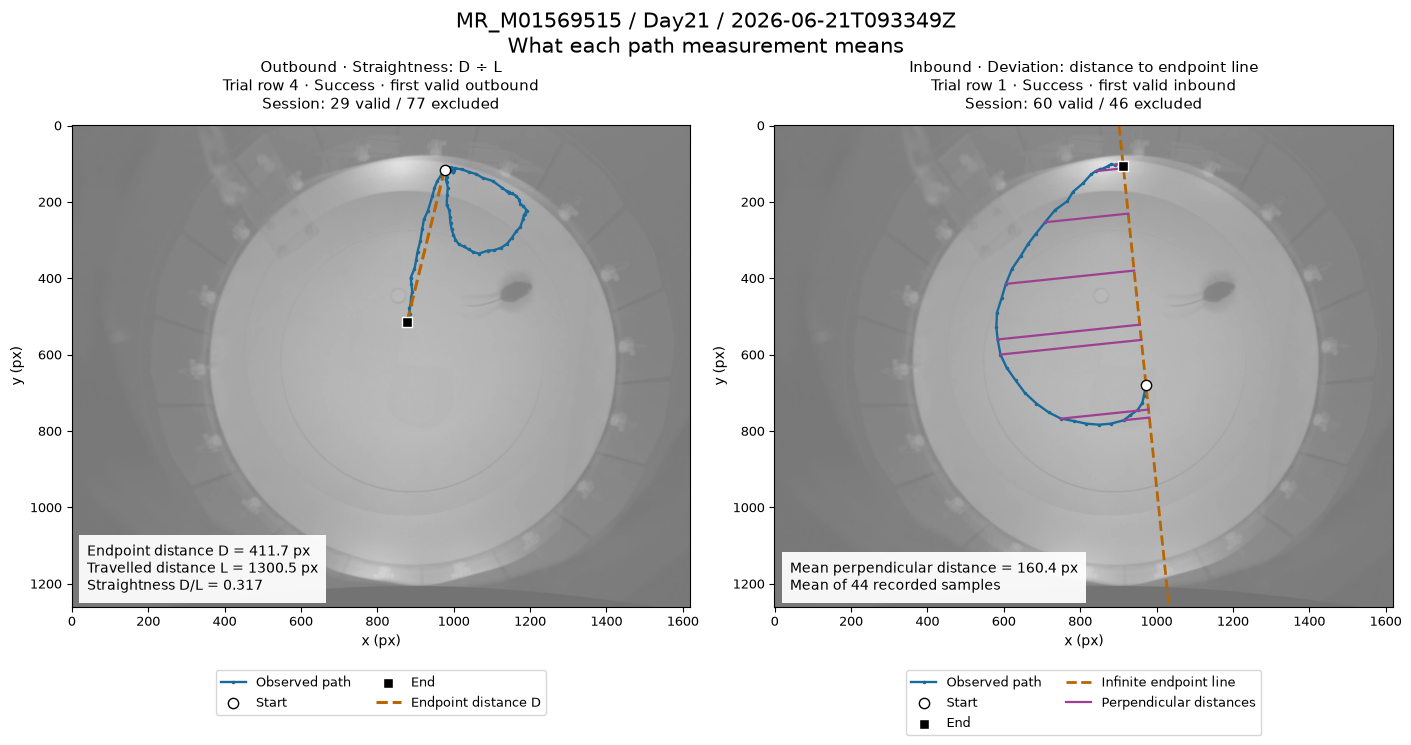

,phase,trial_row,selection,status,valid_phases,excluded_phases
0,outbound,4,first valid outbound,ok,29,77
1,inbound,1,first valid inbound,ok,60,46


In [11]:
#=== 11| Example call: identify and explain eligible trial phases ================
geometry_fig, geometry_axes, example_report = plot_metric_geometry(
    phase_paths, metrics, inbound_deviations, background_frame,
    trial_rows=EXAMPLE_TRIAL_ROWS,
    session_label=session_label,
    arena_range=ARENA_RANGE,
    background_alpha=BACKGROUND_ALPHA,
)
plt.show()
display(example_report)

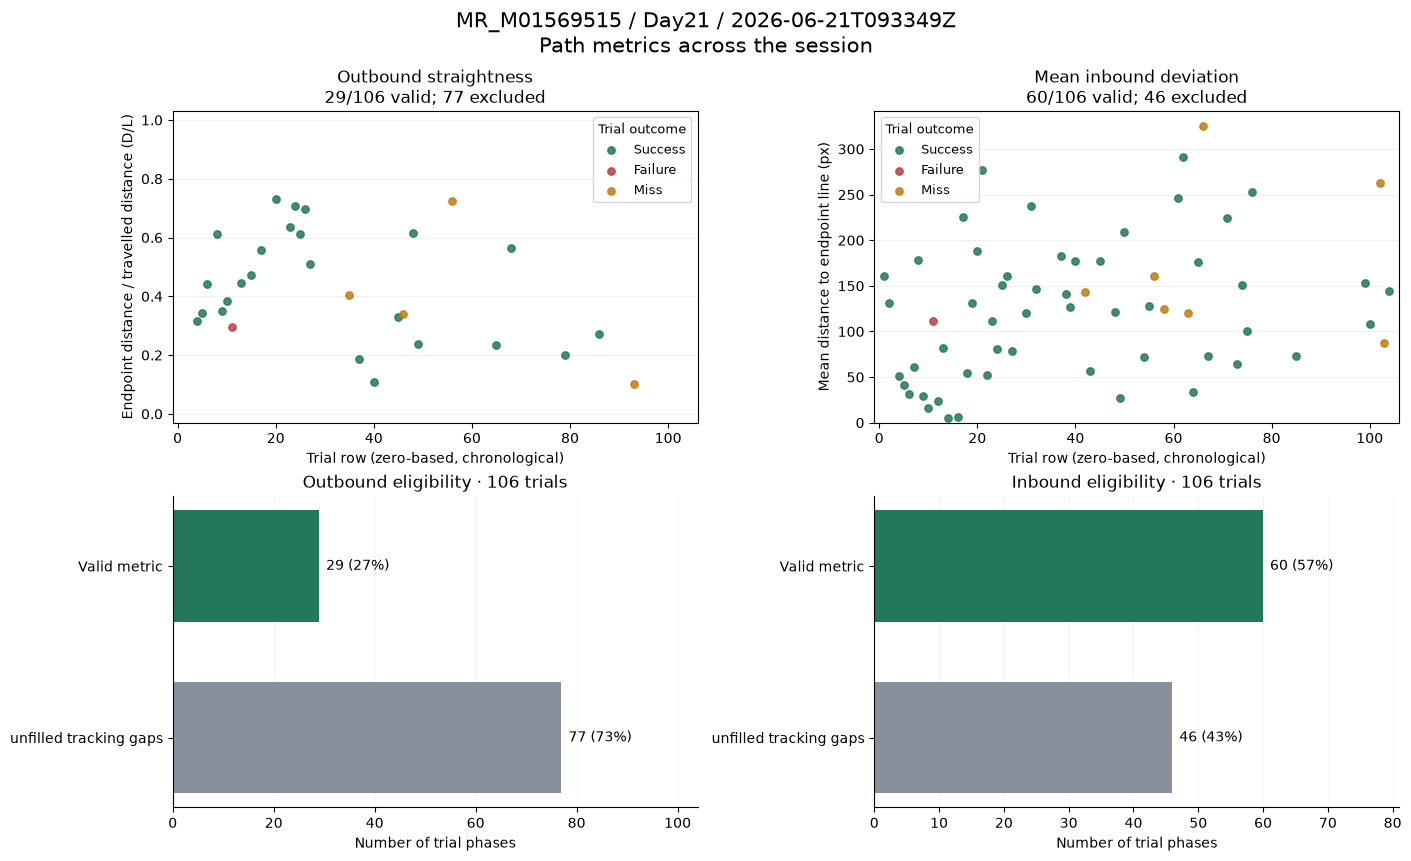

In [12]:
#=== 12| Example call: show measurements and missing-data reasons together ========
summary_fig, summary_axes = plot_trajectory_summary(metrics, session_label=session_label)
plt.show()

## Option 2 — inspect QC-style paths first, with metrics as a secondary table

**Use this to ask:** where did the animal travel outbound and inbound, and how do
those routes look for different trial outcomes?

The columns are outbound/inbound and the default rows are outcomes, following
the QC layout. Read colour as session trial order: light is earlier and dark is
later. The first undistorted frame and shared pixel limits anchor every panel to
the same arena. Set `PATH_GROUP_BY = "trial"` to inspect `TRIAL_ROWS` individually,
or `"session"` to overlay the full session in one row.

Panel counts distinguish visible paths from valid metrics; observed positions can
still be shown when gaps exclude a metric. A small summary table below reports
valid/excluded counts and the median of each available metric for the same
displayed trials. Its metric and units columns make the two definitions explicit;
NaN means that no eligible value is available. The detailed report retains all
exclusion reasons. This option emphasizes routes and spatial context;
use Option 1 when the numerical measurement itself needs explanation.

Outputs are cleared for rerunning with the configured recording. The notebook
does not substitute simulated data if the recording drive is unavailable.

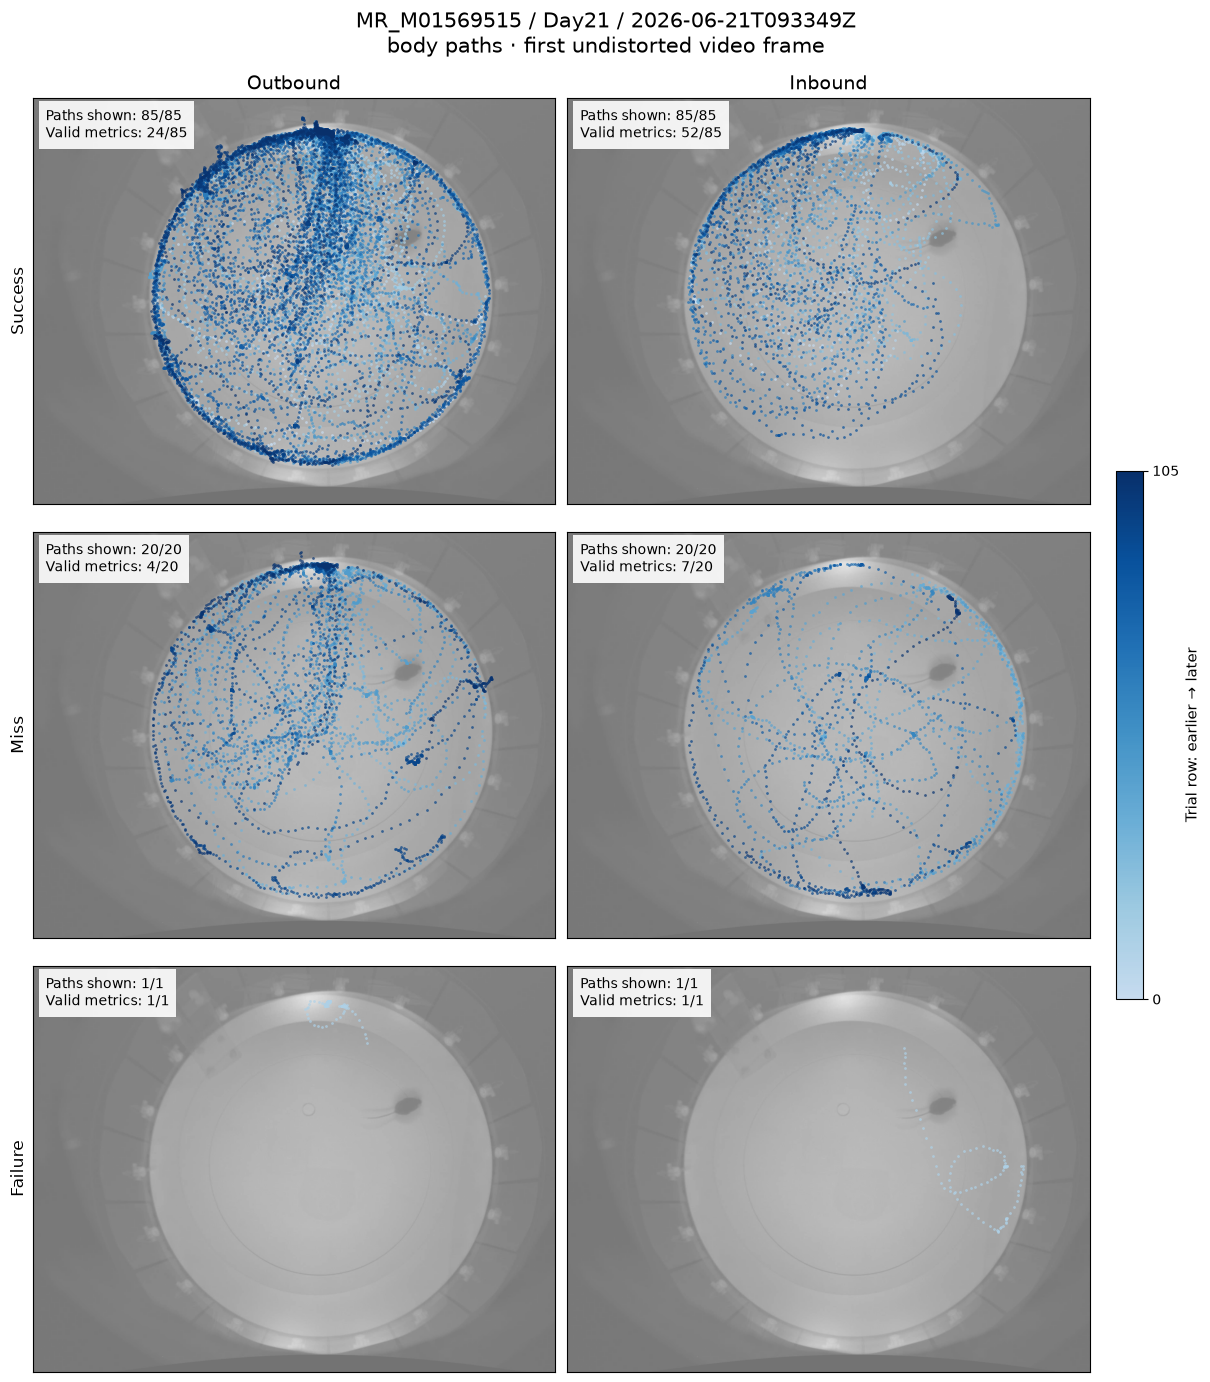

,outcome,phase,path_shown,status,n_trial_phases
0,Success,outbound,True,unfilled tracking gaps,61
1,Success,inbound,True,unfilled tracking gaps,33
2,Success,inbound,True,ok,52
3,Success,outbound,True,ok,24
4,Failure,outbound,True,ok,1
5,Failure,inbound,True,ok,1
6,Miss,outbound,True,unfilled tracking gaps,16
7,Miss,inbound,True,unfilled tracking gaps,13
8,Miss,outbound,True,ok,4
9,Miss,inbound,True,ok,7


,metric,units,n_trials,n_valid,n_excluded,median
phase,,,,,,
outbound,Path straightness (D/L),unitless,106,29,77,0.404
inbound,Mean distance to endpoint line,px,106,60,46,125.349


In [13]:
#=== 13| Example call: all session trials grouped by outcome =====================
path_fig, path_axes, path_report = plot_session_path_grid(
    phase_paths, metrics, background_frame,
    group_by=PATH_GROUP_BY,
    trial_rows=TRIAL_ROWS if PATH_GROUP_BY == "trial" else None,
    session_label=session_label,
    tracking_keypoint=TRACKING_KEYPOINT,
    arena_range=ARENA_RANGE,
    cmap=PATH_CMAP,
    marker_size=PATH_POINT_SIZE,
    path_alpha=PATH_ALPHA,
    background_alpha=BACKGROUND_ALPHA,
)
plt.show()
display(
    path_report.groupby(["outcome", "phase", "path_shown", "status"], sort=False)
    .size().rename("n_trial_phases").reset_index()
)

# Example alternative: set PATH_GROUP_BY = "trial" above and rerun this cell
# for one row per TRIAL_ROWS entry, still with outbound/inbound columns.


# Secondary summary uses exactly the trials displayed in the grid above.
phase_summary = summarise_path_metrics(path_report)
display(phase_summary.round(3))